# Analise 2 - Influência das Plataformas de Redes Sociais nos Níveis de Ansiedade

## 1. Introdução
A experiência do usuário varia drasticamente dependendo da plataforma digital escolhida. O tipo de conteúdo entregue (vídeos curtos em loop, fotos estáticas com filtros, ou discussões em texto) ativa diferentes gatilhos psicológicos nos adolescentes. Esta análise foca em mapear como a escolha da rede social principal pode estar associada a scores variados de ansiedade e isolamento social.

## 2. Objetivo
Os objetivos principais desta seção são:
* Avaliar e comparar a distribuição do nível de ansiedade (`anxiety_level`) entre os usuários das diferentes redes sociais (`platform_usage`).
* Identificar se plataformas baseadas em vídeos curtos e algoritmos de alta retenção (ex: TikTok) apresentam medianas de ansiedade discrepantes em relação a redes mais tradicionais.

## 3. Metodologia
Utilizaremos a mesma base de dados tratada para extrair os recortes por plataforma:
* `dados_limpos.csv`: Base consolidada com dados categóricos padronizados.

### 3.1 Carregamento e Pré-processamento dos Dados

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Garante que os gráficos apareçam no notebook
%matplotlib inline

# Carregando a base tratada
df = pd.read_csv('../../bases/processed/dados_limpos.csv')

    ## 4. Gráficos e Insights

### 4.1 Batalha das Plataformas: Distribuição de Ansiedade por Rede Social
Nesta etapa, utilizamos o gráfico estatístico Boxplot para analisar a dispersão, os quartis e as medianas de ansiedade de cada grupo de usuários:
* **Eixo X (Categórico):** Plataforma Principal Utilizada (`platform_usage`)
* **Eixo Y (Contínuo):** Nível de Ansiedade (`anxiety_level` de 1 a 10)

**Hipótese:** Plataformas focadas no consumo rápido de conteúdo de vídeo (como TikTok e Instagram Reels) apresentam uma caixa de distribuição deslocada para o topo, indicando medianas de ansiedade mais elevadas devido ao estímulo constante de dopamina e comparação social.

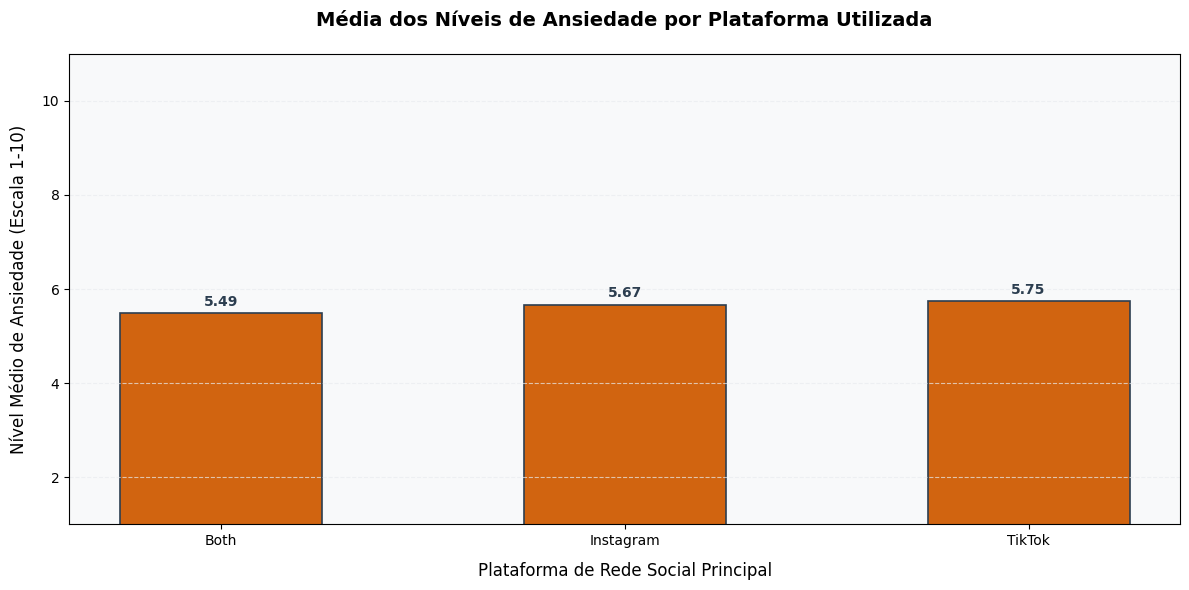

In [ ]:
dados_agrupados = df.groupby('platform_usage')['anxiety_level'].mean().reset_index()

# 2. Configurações estéticas do gráfico
plt.figure(figsize=(12, 6))
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['grid.color'] = '#e9ecef'

# 3. Construção do Gráfico de Barras
barras = plt.bar(
    dados_agrupados['platform_usage'], 
    dados_agrupados['anxiety_level'], 
    color="#d16410",          
    edgecolor='#2c3e50',   
    linewidth=1.2,
    width=0.5                 
)

for barra in barras:    
    altura = barra.get_height()
    plt.annotate(
        f'{altura:.2f}',
        xy=(barra.get_x() + barra.get_width() / 2, altura),
        xytext=(0, 3),        
        textcoords="offset points",
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold',
        color='#2c3e50'
    )

# 5. Customização de títulos e rótulos
plt.title('Média dos Níveis de Ansiedade por Plataforma Utilizada', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Plataforma de Rede Social Principal', fontsize=12, labelpad=10)
plt.ylabel('Nível Médio de Ansiedade (Escala 1-10)', fontsize=12, labelpad=10)

# Define o limite do eixo Y de 1 a 10
plt.ylim(1, 11)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### 4.1.1 Conclusão
Ao analisar o gráfico de barras gerado, podemos apontar as seguintes conclusões sobre os índices de ansiedade:

* **Maior Pico de Ansiedade:** O TikTok registrou o maior índice médio isolado, com 5.75 na escala de ansiedade, seguido de perto pelo Instagram, que marcou 5.67. Esses resultados evidenciam que ambas as plataformas, seja pelo formato de vídeos curtos em loop ou pelo forte apelo visual de status e estética performática, estão associadas a scores elevados de sobrecarga psicológica nos jovens.
* **Comportamento do Uso Combinado:** O grupo que declarou utilizar ambas as redes ("Both", que em português significa ambas) apresentou a menor média entre os três cenários (5.49). Embora ainda seja um valor alto, esse comportamento indica que a alternância entre plataformas não gerou um efeito cumulativo ou multiplicador na ansiedade da amostra avaliada, o que a primeira vista pode parecer contraintuitivo.
* **Validação:** A hipótese de que o tipo de consumo digital gera variações nos níveis de ansiedade foi **parcialmente confirmada**. Embora todas as médias tenham ficado concentradas em uma faixa alta (entre 5.40 e 5.80), o TikTok e o Instagram isolados mostraram-se ligeiramente mais associados a sintomas severos de ansiedade do que o uso combinado de ambos.